# Chaper 3 - CNN Exercises
## 1. Training all the revised networks of this chapter with 40 epochs

In [ ]:
# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * 

print(" dl_utils loaded")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
 dl_utils loaded


In [27]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
#from idlmam import *
from sklearn.metrics import accuracy_score

In [28]:
# Downloading the MNIST data set
mnist_data_train = torchvision.datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
mnist_data_test = torchvision.datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())

In [35]:
# Verification of CUDA present

torch.backends.cudnn.benchmark = True  # Speeds up CNN training with fixed input sizes

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Device available: {device}')

Device available: cuda


In [30]:
# Create a DataLoaders
B = 32 #Batch size
mnist_train_loader = DataLoader(mnist_data_train, batch_size=B, shuffle=True)
mnist_test_loader = DataLoader(mnist_data_test, batch_size=B)

In [31]:
# CREATING THE CNN MODEL

# Determine de layers of subsequent layers
D = 28*28
# Channels in the input (1 for grayscale)
C = 1
# Number of classes
classes = 10
# Number of filters used
filters = 16
# filters size
K = 3

# Define Loss Function
loss_func = nn.CrossEntropyLoss()

In [32]:


# Define a linear model for comparison
model_linear = nn.Sequential(
    nn.Flatten(), # (B, C, W, H) -> (B, C*W*H) = (B, D)
    nn.Linear(D, 256),
    nn.Tanh(),
    nn.Linear(256, classes)
)

# Now the simple CNN. Conv2d
model_cnn = nn.Sequential(
    nn.Conv2d(C, filters, K, padding=K//2), # x(conv)D
    nn.Tanh(),
    nn.Flatten(),
    nn.Linear(filters*D, classes)
)

In [ ]:
# TRAINING THE MODELS

# FULLY CONNECTED MODEL
fc_results = train_simple_network_EZA(model_linear, loss_func,
                                  mnist_train_loader, test_loader=mnist_test_loader,
                                  score_funcs={'Accuracy': accuracy_score},
                                  device=device,
                                  epochs=40)

In [ ]:
# CNN MODEL
cnn_results = train_simple_network_EZA(model_cnn, loss_func,
                                   mnist_train_loader,
                                   test_loader=mnist_test_loader,
                                   score_funcs={'Accuracy': accuracy_score},
                                   device=device,
                                   epochs=40)

<Axes: xlabel='epoch', ylabel='test Accuracy'>

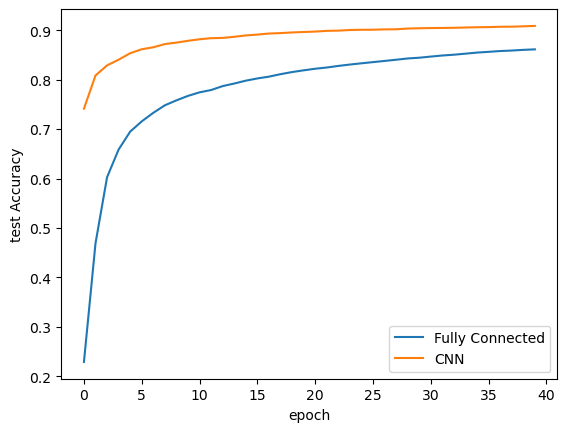

In [29]:
# COMPARE MODELS

sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='Fully Connected')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results, label='CNN')

In [39]:
# The "TRANSLATION INVARIANCE" property of CNN partialy added by "MAX POOLING".

model_cnn_pool = nn.Sequential(
    nn.Conv2d(C, filters, 3, padding=3//2),
    nn.Tanh(),
    nn.Conv2d(filters, filters, 3, padding=3//2),
    nn.Tanh(),
    nn.Conv2d(filters, filters, 3, padding=3//2),
    nn.Tanh(),
    nn.MaxPool2d(2),
    nn.Conv2d(filters, 2*filters, 3, padding=3//2),
    nn.Tanh(),
    nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
    nn.Tanh(),
    nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
    nn.Tanh(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(2*filters*D//(4**2), classes)
)

In [45]:
# RESULTS
cnn_results_with_pool = train_simple_network_EZA(model_cnn_pool, loss_func,
                                             mnist_train_loader, 
                                             test_loader=mnist_test_loader,
                                             score_funcs={'Accuracy': accuracy_score},
                                             device=device,
                                             epochs=5)

Epoch: 100%|██████████| 5/5 [01:08<00:00, 13.78s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

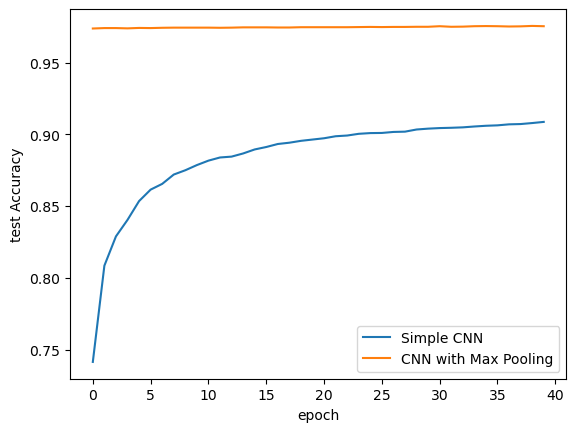

In [35]:
# Accuracy of the CNN pooled model

sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results, label='Simple CNN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results_with_pool, label='CNN with Max Pooling')

In [36]:
# Usage of a sequence of transformations using "transforms.Compose"
train_transform = transforms.Compose(
    [transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.98, 1.02)),
     transforms.ToTensor()]
)

test_transform = transforms.ToTensor()
mnist_train_t = torchvision.datasets.MNIST("./data", train=True, transform=train_transform)
mnist_test_t = torchvision.datasets.MNIST("./data", train=False, transform=test_transform)

mnist_train_loader_t = DataLoader(mnist_train_t, shuffle=True, batch_size=B, num_workers=6)
mnist_test_loader_t = DataLoader(mnist_test_t, batch_size=B, num_workers=6)

In [46]:
# Train the CNN_pooled with the transformed data from the DataLoader
cnn_results_with_pool_augmented = train_simple_network_EZA(model_cnn_pool,
                                                       loss_func,
                                                       mnist_train_loader_t,
                                                       test_loader=mnist_test_loader_t,
                                                       score_funcs={'Accuracy' : accuracy_score},
                                                       device=device,
                                                       epochs=5)

Epoch: 100%|██████████| 5/5 [01:03<00:00, 12.64s/it]


(0.95, 1.0)

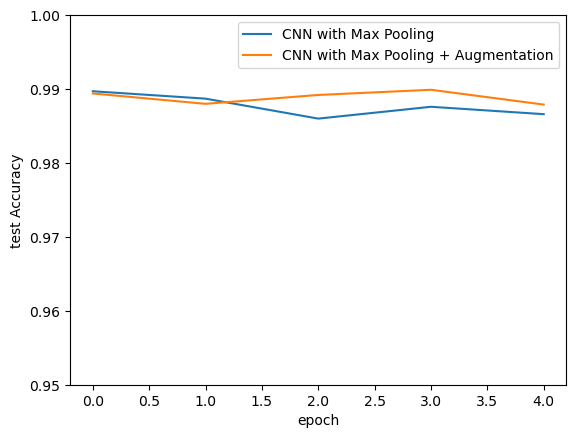

In [47]:
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results_with_pool, label='CNN with Max Pooling')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results_with_pool_augmented, label='CNN with Max Pooling + Augmentation')
plt.ylim(0.95 ,1)